In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:

ruta = "./Dataset__censadata.csv"
df=pd.read_csv(ruta,delimiter=";")


In [ ]:
df.describe()

,NumCasa,IngresoPersonal,Edad,Grado
count,2500.000000,2500.000000,2500.000000,2500.000000
mean,1246.997200,7834.800000,40.520000,2.479200
std,143.564862,7097.750361,23.145572,1.561583
min,1001.000000,0.000000,1.000000,1.000000
25%,1120.000000,0.000000,20.000000,1.000000
50%,1247.000000,9500.000000,41.000000,2.000000
75%,1369.000000,13500.000000,61.000000,4.000000
max,1500.000000,21000.000000,80.000000,5.000000


In [7]:
#revisamos si existen datos nulos
df.isnull().sum()
  

NumCasa            0
Nombre             0
IngresoPersonal    0
Empleo             0
Edad               0
Sexo               0
EstadoCivil        0
NivelEducativo     0
Grado              0
barrio             0
dtype: int64

In [5]:
# revisamos el tipo de datos de cada columna
df.dtypes

NumCasa            int64
Nombre               str
IngresoPersonal    int64
Empleo               str
Edad               int64
Sexo                 str
EstadoCivil          str
NivelEducativo       str
Grado              int64
barrio               str
dtype: object

<Axes: xlabel='Edad'>

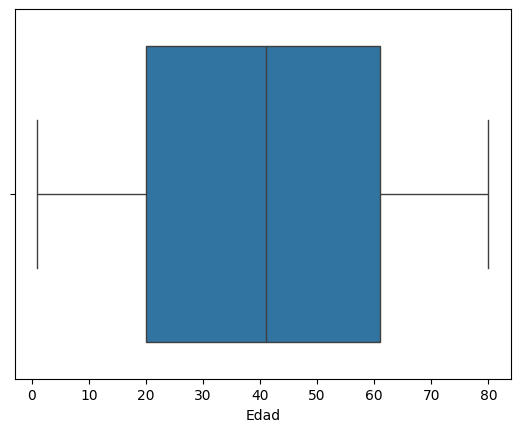

In [6]:
#revisamos si hay datos atípicos en las edades de los encuestados
sns.boxplot(x=df["Edad"])   

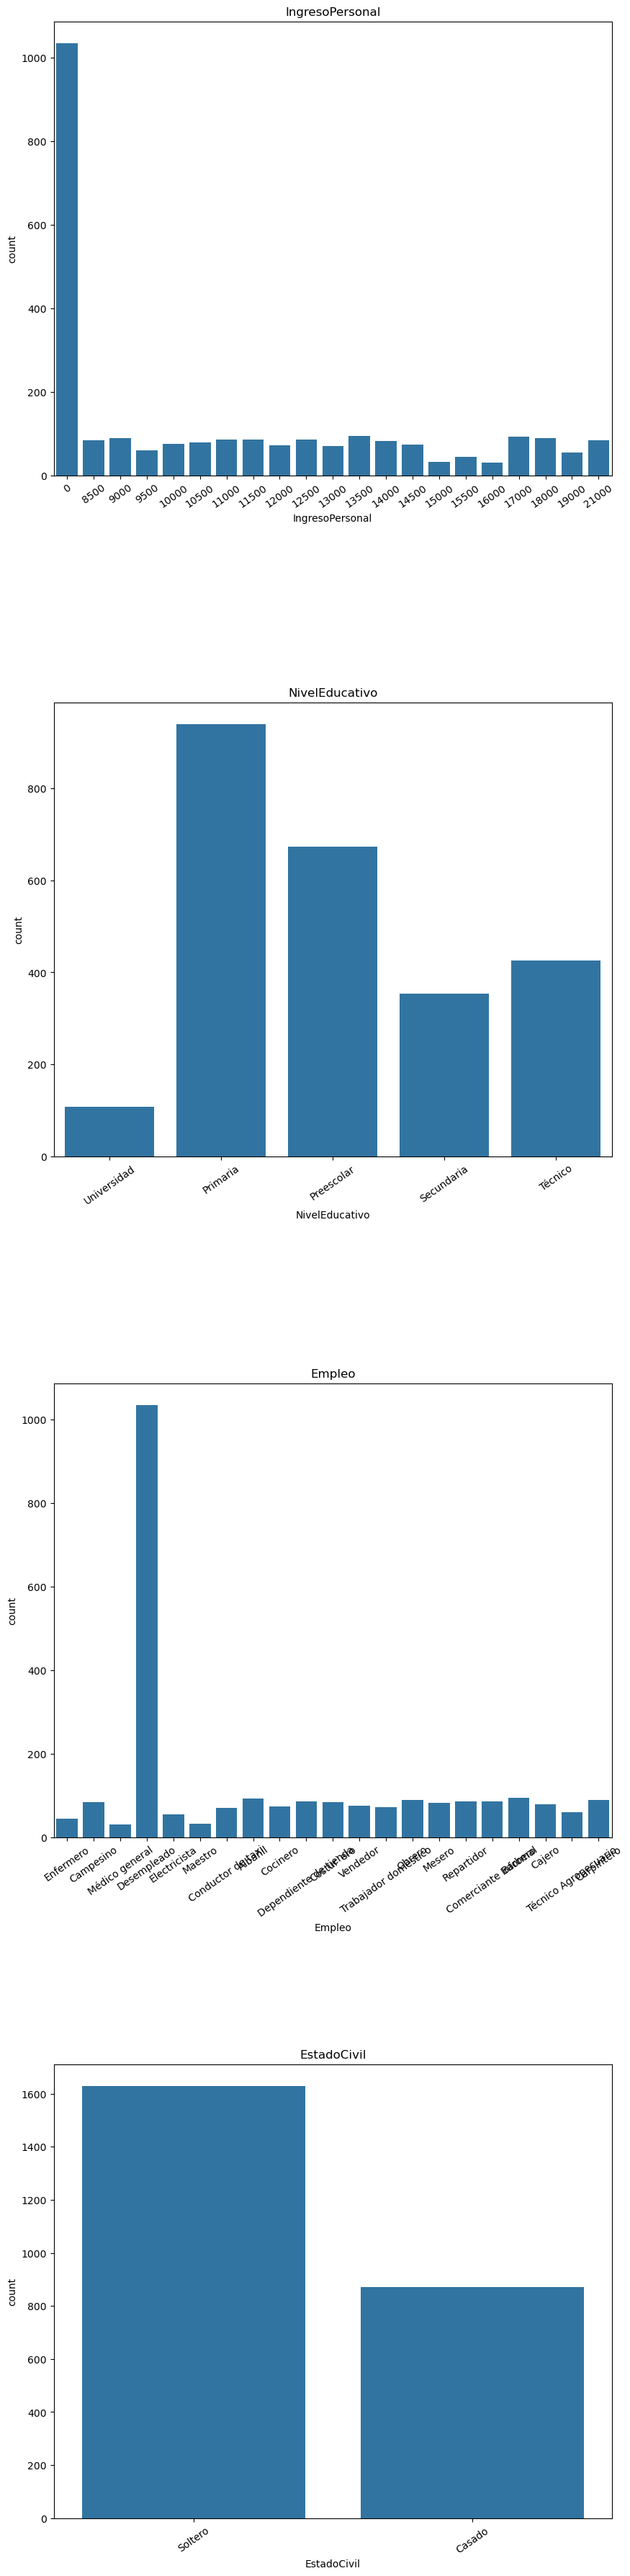

In [ ]:
col_cat = ['IngresoPersonal', 'NivelEducativo', 'Empleo', 'EstadoCivil']

# Gráficos de barras de conteo
fig, ax = plt.subplots(nrows=len(col_cat), ncols=1,figsize=(10,45))
fig.subplots_adjust(hspace=0.5)

for i, col in enumerate(col_cat):
  sns.countplot(x=col, data=df, ax=ax[i])
  ax[i].set_title(col)
  
  for tick in ax[i].get_xticklabels():
    tick.set_rotation(35)
  

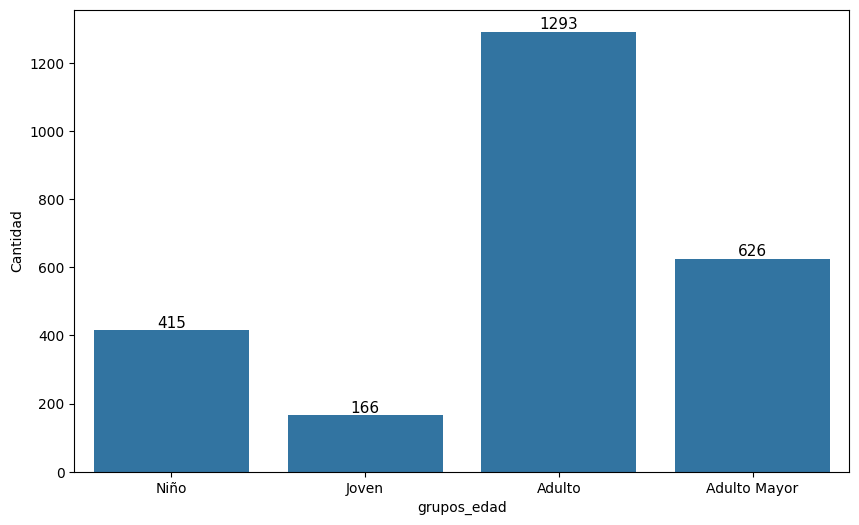

In [32]:
# clasificamos las edades en grupos 

bins = [0 ,13, 18, 60, 100]
labels = ['Niño', 'Joven', 'Adulto', 'Adulto Mayor']

df['grupos_edad'] = pd.cut(
    df['Edad'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

conteo_edades = (
    df.groupby('grupos_edad', observed=False)
      .size()
      .reset_index(name='Cantidad')
)


plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x='grupos_edad',
    y='Cantidad',
    data=conteo_edades
)


for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11
    )

<Axes: xlabel='NivelEducativo', ylabel='IngresoPersonal'>

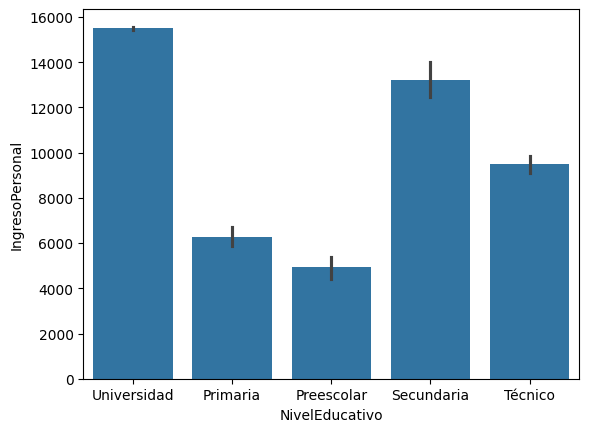

In [ ]:
# Sumar ingresos por nivel educativo
ingresos_totales = df.groupby('NivelEducativo', as_index=False)['IngresoPersonal'].count()
#creamos un grafico de barras para analizar la relación entre el nivel educativo y el ingreso personal
sns.barplot(x='NivelEducativo', y='IngresoPersonal', data=df)



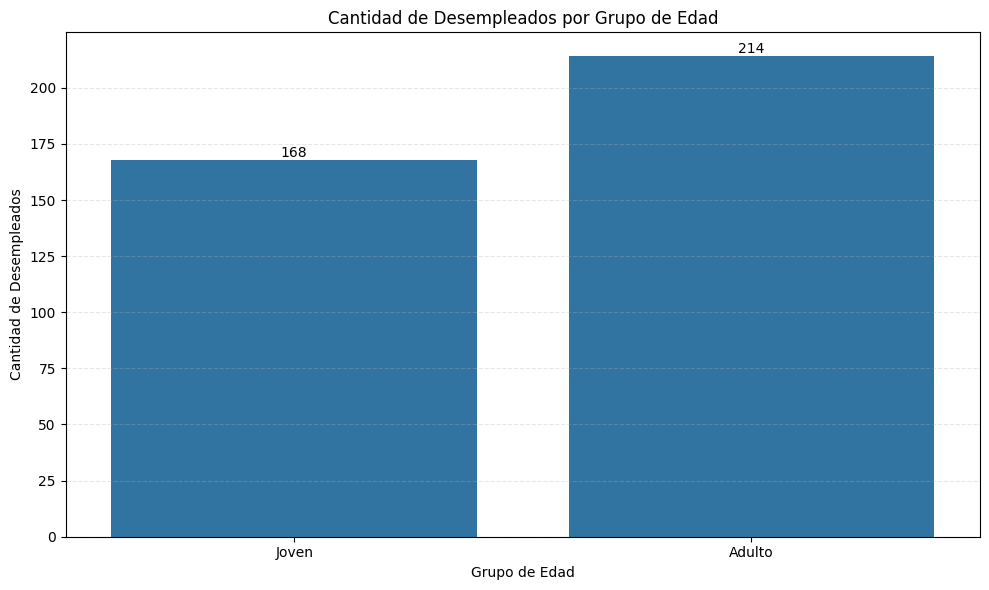

In [ ]:
#Creamos un grsfico de barra para analizar la cantidad de desempleados por edad

bins = [ 18, 35, 60]
labels = [ 'Joven', 'Adulto']

df['grupos_trabajo'] = pd.cut(
    df['Edad'],
    bins=bins,
    labels=labels,
    include_lowest=True
)
# Filtrar desempleados
desempleados = df[df['Empleo'] == 'Desempleado']

# Contar desempleados por grupo de edad
conteo = (
    desempleados.groupby('grupos_trabajo' , observed=False)
    .size()
    .reset_index(name='Cantidad')
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x='grupos_trabajo',
    y='Cantidad',
    data=conteo
)


for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Cantidad de Desempleados por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Desempleados')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

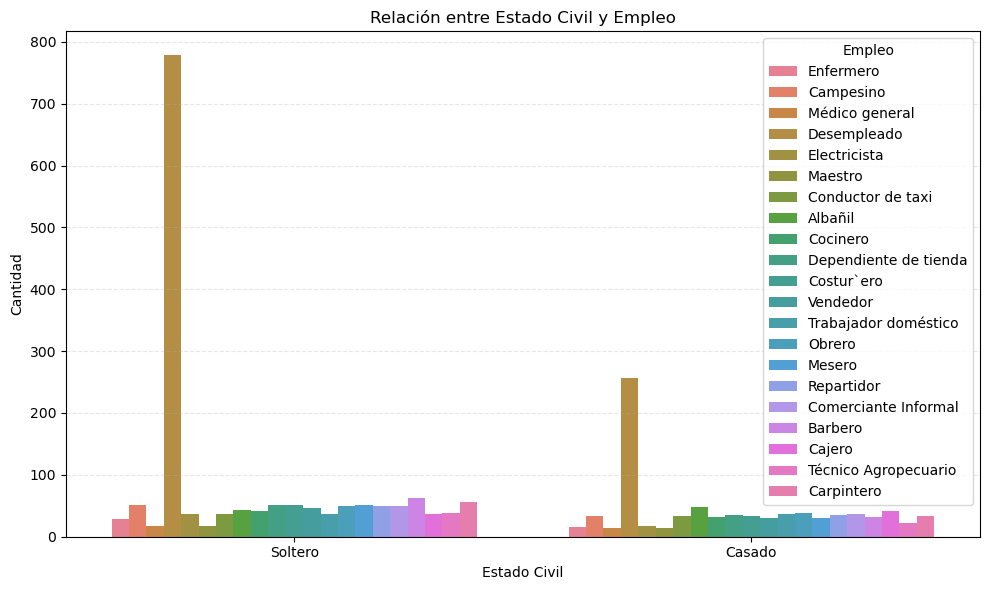

In [10]:
# Analizar la relación entre el estado civil y el empleo




plt.figure(figsize=(10, 6))
sns.countplot(x='EstadoCivil', hue='Empleo', data=df)
plt.title('Relación entre Estado Civil y Empleo')
plt.xlabel('Estado Civil')
plt.ylabel('Cantidad')
plt.legend(title='Empleo')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()



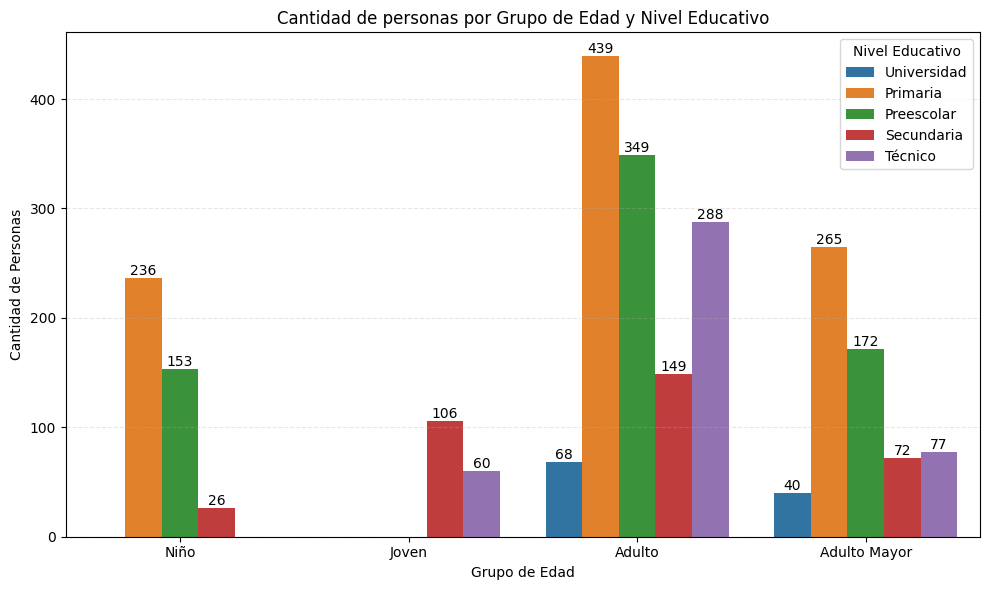

In [35]:
#analizamos la relacion entre el grupo de edad y el nivel educativo


plt.figure(figsize=(10, 6))

ax = sns.countplot(
    x='grupos_edad',
    hue='NivelEducativo',
    data=df
)


for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.title('Cantidad de personas por Grupo de Edad y Nivel Educativo')
plt.ylabel('Cantidad de Personas')
plt.xlabel('Grupo de Edad')
plt.legend(title='Nivel Educativo')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()



In [36]:
cantidad_niños_con_ingreso = df.query(
    "grupos_edad == 'Niño' and IngresoPersonal > 0"
).shape[0]

print(f'Cantidad de niños con ingreso personal mayor a 0: {cantidad_niños_con_ingreso}')

Cantidad de niños con ingreso personal mayor a 0: 0


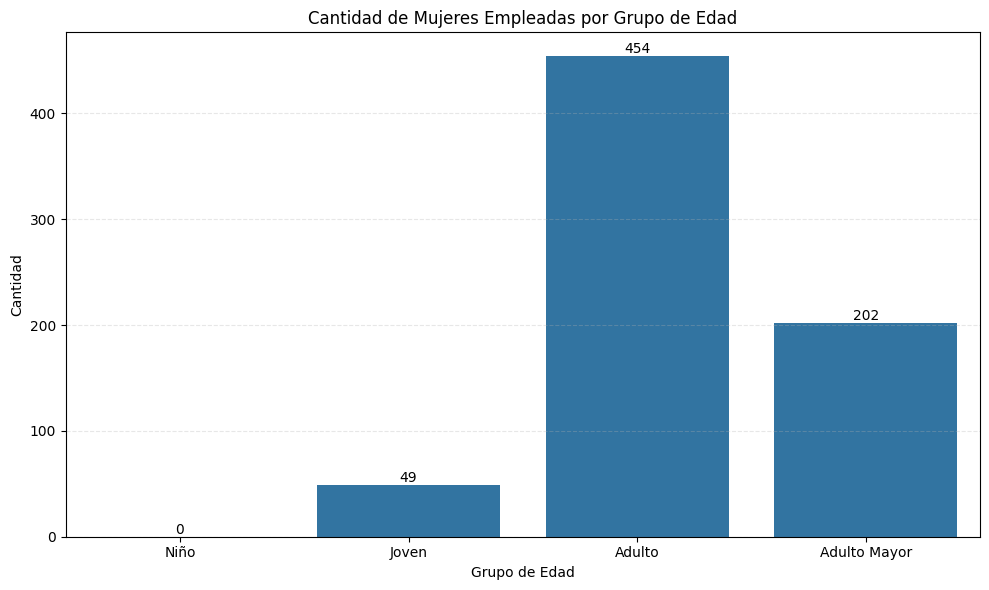

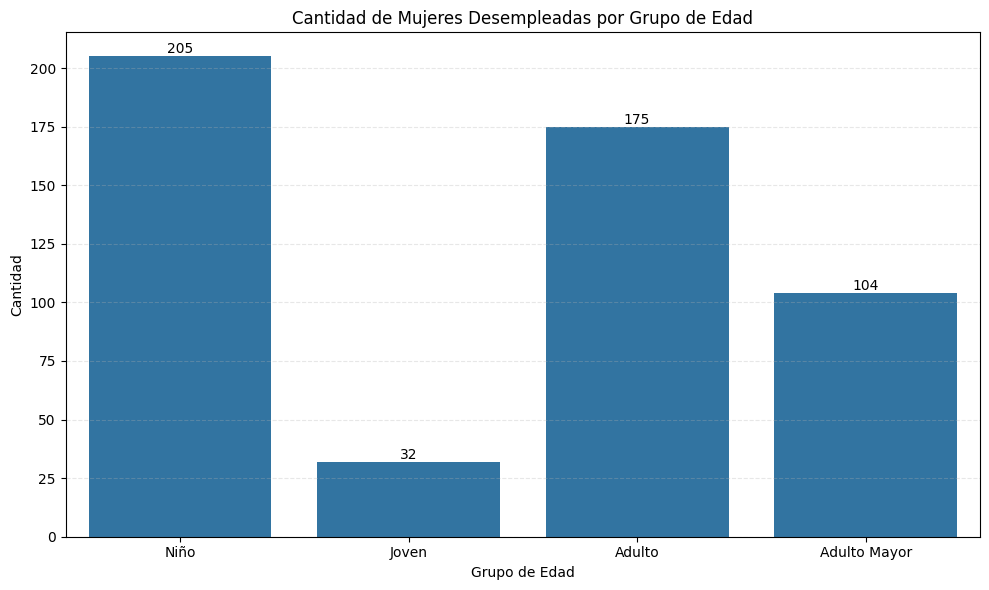

In [ ]:


# Mujeres desempleadas agrupadas por edad
cantidad_de_Mujeres_Desempleadas_Por_edades = (
    df.query("Empleo == 'Desempleado' and Sexo == 'F'")
      .groupby('grupos_edad', observed=False)
      .size()
      .reset_index(name='Cantidad')
)

# Mujeres empleadas agrupadas por edad
cantidad_de_Mujeres_Empleadas_Por_edades = (
    df.query("Empleo != 'Desempleado' and Sexo == 'F'")
      .groupby('grupos_edad', observed=False)
      .size()
      .reset_index(name='Cantidad')
)
# Gráfico
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x='grupos_edad',
    y='Cantidad',
    data=cantidad_de_Mujeres_Empleadas_Por_edades
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Cantidad de Mujeres Empleadas por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x='grupos_edad',
    y='Cantidad',
    data=cantidad_de_Mujeres_Desempleadas_Por_edades
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Cantidad de Mujeres Desempleadas por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


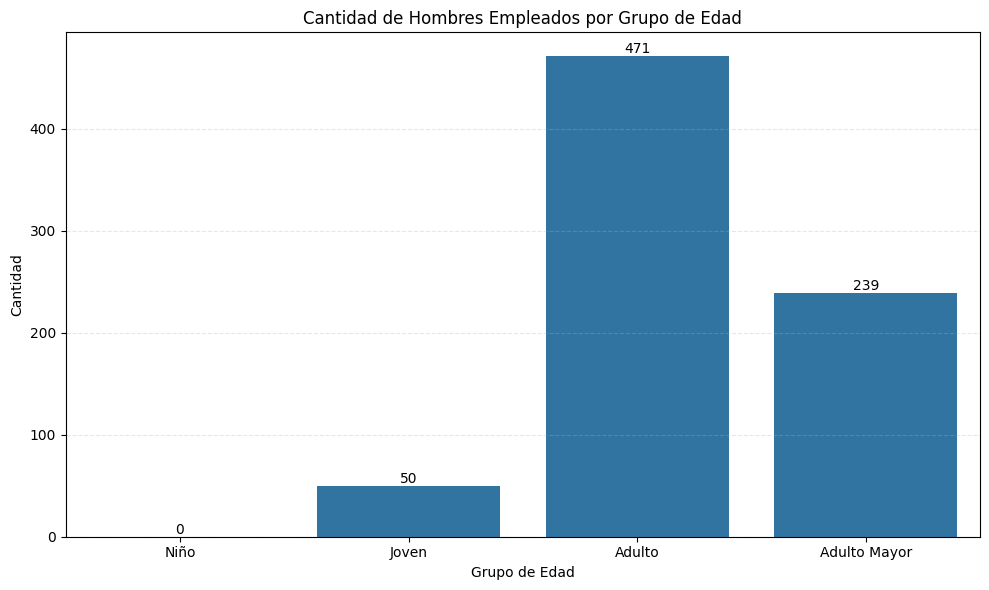

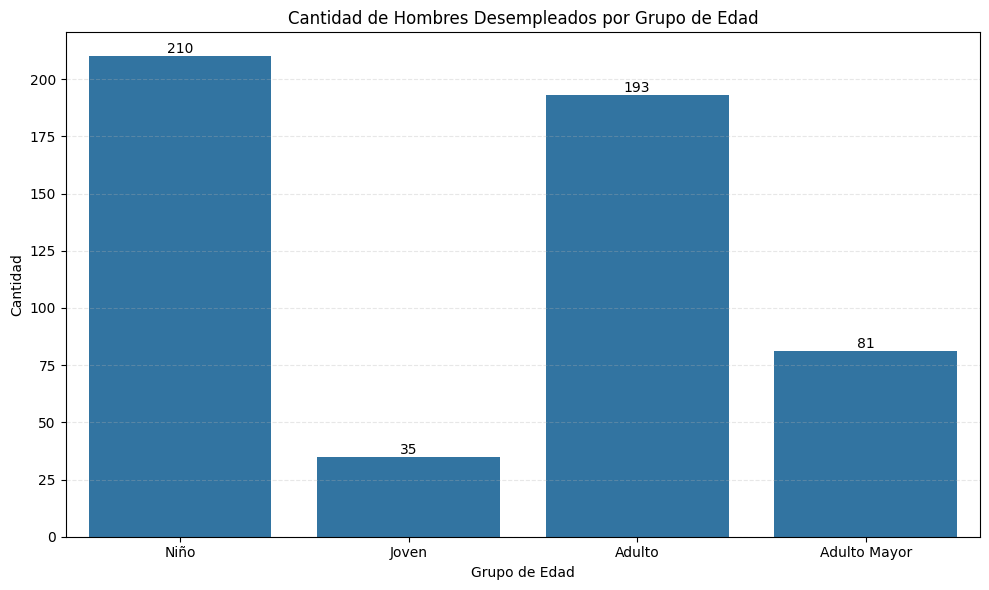

In [ ]:
# Hombres desempleados agrupadas por edad
cantidad_de_Hombres_Desempleados_Por_edades = (
    df.query("Empleo == 'Desempleado' and Sexo == 'M'")
      .groupby('grupos_edad', observed=False)
      .size()
      .reset_index(name='Cantidad')
)

# Hombres empleados agrupados por edad
cantidad_de_Hombres_Empleados_Por_edades = (
df.query("Empleo != 'Desempleado' and Sexo == 'M'")
    .groupby('grupos_edad', observed=False)
    .size()
    .reset_index(name='Cantidad')
)
# Gráfico
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x='grupos_edad',
    y='Cantidad',
    data=cantidad_de_Hombres_Empleados_Por_edades
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Cantidad de Hombres Empleados por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x='grupos_edad',
    y='Cantidad',
    data=cantidad_de_Hombres_Desempleados_Por_edades
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Cantidad de Hombres Desempleados por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

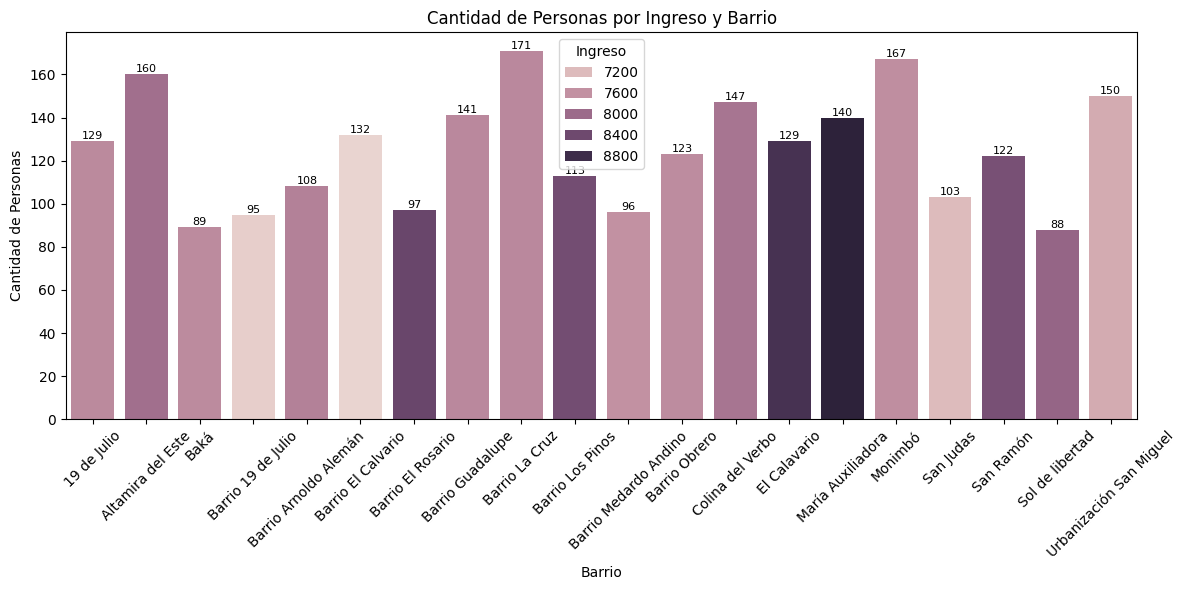

In [39]:
df_barrios = (
    df.groupby('barrio')
      .agg(
          Personas=('IngresoPersonal', 'count'),
          IngresoPromedio=('IngresoPersonal', 'mean')
      )
      .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=df_barrios,
    x='barrio',
    y='Personas',
    hue='IngresoPromedio'
)

for p in ax.patches:
    altura = p.get_height()
    if altura > 0:
        ax.annotate(
            f'{int(altura)}',
            (p.get_x() + p.get_width()/2, altura),
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.title('Cantidad de Personas por Ingreso y Barrio')
plt.xlabel('Barrio')
plt.ylabel('Cantidad de Personas')
plt.xticks(rotation=45)
plt.legend(title='Ingreso')
plt.tight_layout()
plt.show()